# Woodpile beam-spreading experiment (focused Gaussian beam, exit-face field)

Replicates the LSU "beam spreading vs frequency" numerical experiment on the woodpile photonic crystals in
`../Structures`. A **focused Gaussian beam** is launched onto the entrance face (`z = -t_slab_z/2`) and the
**complex E-field on the exit face** (`z = +t_slab_z/2`) is recorded with a frequency-domain `FieldMonitor`, so that
the transverse intensity `I(x, y; ν)` and its width `σ²(ν)`, `d(ν)` can be analysed afterwards. An identical
entrance-face monitor records the incident spot in the same run, and an **empty-box reference** (`sim0`, same grid,
no structures) is submitted once per structure to normalise the exit field and measure the free-space spot.

The structure is built from **native tidy3d geometry** (`td.Cylinder` objects in one `td.GeometryGroup`) taken from the
`rods` and `defects` tables stored in each `*_tables.h5` — never from the voxelised `epsilon` array and never through
`AM.loadAndRunStructure`. Reference implementation mirrored:
`LSU Project/20251001_LSU_Localization_Tests/20260601_Beam_Spreading_freq/20251001_numerical_experiment_using_td_cylinders.py`.

## Deliberate differences from the reference script

* **API key.** The reference never calls `web.configure` (it worked because `AutomationModule` was imported elsewhere).
  Here `AM.loadAndRunStructure` is bypassed, so `web.configure(os.environ["API_TIDY3D_KEY"])` is called explicitly after
  `load_dotenv()`. The retrieval notebook gets the key through `AM.loadFromFile(key=...)`.
* **No `numpy-stl`.** `from stl import mesh` was only used for the rotation matrix of tilted cylinders. Woodpile rods
  are axis-aligned, so `create_cylinder_from_ends` builds `td.Cylinder(axis=...)` from the end-points directly; it asserts
  that the two end-points differ in exactly one coordinate and raises otherwise.
* **No rescaling, no clipping, no hard-coded radius.** The reference divided positions by 0.8, dropped cylinders whose
  centre lay outside `±t_slab_z/2 ± 0.8` and used `radius = 0.42`. Here the tables are in µm at scale 1, all rods lie
  inside the box, and radii come from the tables (`minor_radius` per rod / per defect).
* **Source.** The reference used a 5×5 µm `PlaneWave` patch. Here the default is a `td.GaussianBeam` with a defined waist
  on the entrance face; a `source_kind = "planewave_patch"` switch reproduces the reference's patch
  (`z = -t_slab_z/2 - 1`, `size=(S, S, 0)`) so a like-for-like comparison with the LSU runs stays possible.
* **Absorbers.** Reference: 200 layers; woodpile transmission run: 130. Here **130** (parameter `absorbers`), the same
  as the transmission run.
* **Empty-box reference `sim0`.** Not in the reference script (taken from the transmission notebook) — needed to
  normalise the exit field and measure the free-space spot. Its grid is pinned to the structure grid with
  `td.GridSpec.from_grid(sim.grid)`.
* **Task name** encodes the band, `f"{stem}_lambda_{lambdas[1]}_{lambdas[0]}"`, so a rerun with a different band is not
  skipped by the "Exist!" check.
* **No blanket `try/except`** around the file loop: exceptions propagate so a malformed table is never silently skipped.
* **Maxwell-Garnett `e_eff`/`n_eff` block and `cube1`/`cube2`** dropped (they were `n_eff = 1` no-ops).

## Pilot-box caveat

The current structures are a **12 × 12 × 8.49 µm pilot box** (10 × 10 pitches, 5 FCC cells = 20 layers). The transverse
simulation size is exactly `params["box_size"]`, with the absorbing layers added outside by tidy3d, so any lateral
spreading beyond `±6 µm` is **clipped by the absorbers**. Nothing structure-specific is typed by hand: the loop reads
box size, rods, defects and permittivity from each `*_tables.h5`, so larger structures generated later run unchanged.

**Nothing is submitted unless `run = True`** — the default `run = False` branch only uploads a throw-away copy to get
`web.estimate_cost`, deletes it, and plots the layout.


In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from tidy3d import web

# AutomationModule lives in the root of the tidy3d project (only read_hdf5_as_dict is used here)
sys.path.append(os.path.abspath(r'H:\codes\tidy3d'))
import AutomationModule as AM

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
web.configure(tidy3dAPI)          # explicit: this notebook does not go through AM.loadAndRunStructure
print("tidy3d", td.__version__)


Configured successfully.


tidy3d 2.9.1


## Parameters

The only hand-set physics parameters are `lambdas`, `w0`, `runtime_ps`, `min_steps_per_lambda` and `absorbers`.
Everything geometric (`box_size`, `d`, `permittivity`, radii, rod/defect end-points) comes from `params`, `rods` and
`defects` in each structure file.

### Frequency window — from the measured transmission

`../data/20260918_transmission_data_woodpiles.h5` was recorded over λ ∈ [1.5, 3.5] µm (plane wave along z). The windows
with `T_exit < 1e-2` are (printed again by the next cell from the file itself):

| structure | κ | T_exit < 1e-2 window (µm) | min T_exit |
|---|---|---|---|
| crystal | 0 | [2.57, 3.20] | 2e-4 at 2.82 µm |
| defects ρ = 0.1 | +1.2 | [2.86, 3.15] | 8e-4 at 2.97 µm |
| defects ρ = 0.1 | +1.6 | [2.99, 3.14] | 3e-3 at 3.02 µm |
| defects ρ = 0.1 | +2.8 | none | 0.036 at 3.15 µm |

The stacking-direction gap of the crystal spans λ ≈ 2.57–3.20 µm (ν = d/λ ≈ 0.375–0.467) and fills in progressively
with defect scattering. `lambdas = [3.5, 2.0] µm` (ν ≈ 0.343–0.600) covers the whole gap plus both pass-band flanks:
≈0.3 µm of margin on the long-λ side (limited by the transmission data, which stops at 3.5 µm) and ≈0.6 µm on the
short-λ side, where the higher pass band of the crystal lives.

### Beam waist

`w0 = 1.5 µm` (≈ λ/2 at the gap centre, λ ≈ 2.9 µm). The next cell prints the free-space NA ≈ λ/(π w0) and Rayleigh
range z_R = π w0²/λ at the band edges and the gap centre. The waist sits **on the entrance face**: the source plane is
1 µm below it and, in tidy3d 2.9.x, a *positive* `waist_distance` puts the waist **behind** the source, so
`waist_distance = -(z_face - z_src) = -1 µm` (verified numerically at the end of the notebook).

### Grid

`td.GridSpec.auto(min_steps_per_wvl=18, wavelength=lambdas[0], dl_min=dl, max_scale=1.2)` with
`dl = (λ_min/18)/n_rod`, exactly as in the reference. Note that `wavelength=lambdas[0]` is the **longest** wavelength,
so the auto mesher targets 18 steps per λ_max; the resulting step inside the rods (printed below) therefore resolves
λ_min/n_rod with fewer steps (≈10) and the rod diameter with ≈7 cells. This mirrors the reference/transmission settings;
tighten `min_steps_per_lambda` if the analysis turns out to be resolution-sensitive.


In [2]:
# ---------------- hand-set parameters ----------------
lambdas = np.array([3.5, 2.0])      # [lambda_max, lambda_min] in um (same ordering as the reference)
w0 = 1.5                            # Gaussian-beam waist radius (um), waist on the entrance face
runtime_ps = 22e-12                 # run time in seconds (shutoff=1e-20 will end the run earlier if the field decays)
min_steps_per_lambda = 18
absorbers = 130                     # same absorber count as the woodpile transmission run
source_kind = "gaussian"            # "gaussian" (default) | "planewave_patch" (reference-like 5x5 um patch)
patch_size = 5.0                    # only for source_kind == "planewave_patch"
src_offset = 1.0                    # source plane sits this far below the entrance face (um)
band_width = 0.01                   # a/lambda band width for the spectral_sampling report
run = False                         # <<< leave False; the user flips it to submit. False = estimate cost + plots only.

project_name = "20260918_Beam_Spreading_Experiment_woodpiles"
folder_path = Path("../Structures")
transmission_file = Path("../data/20260918_transmission_data_woodpiles.h5")

f_min, f_max = td.C_0 / lambdas[0], td.C_0 / lambdas[1]
f0 = 0.5 * (f_min + f_max)

# ---------------- transmission windows (from the measured data) ----------------
tdata = AM.read_hdf5_as_dict(str(transmission_file))
lam_T = np.asarray(tdata["lambda"])
d_ref = None
print("T_exit < 1e-2 windows from", transmission_file.name)
for key, val in tdata["transmission_data"].items():
    T = np.asarray(val["transmission_exit"])
    m = T < 1e-2
    win = (lam_T[m].min(), lam_T[m].max()) if m.any() else None
    print(f"  {key[:60]:60s} min T = {T.min():.1e} at {lam_T[T.argmin()]:.2f} um, window = "
          + (f"[{win[0]:.2f}, {win[1]:.2f}] um" if win else "none"))

# ---------------- beam numbers (free space) ----------------
print(f"\nBand: lambda = [{lambdas[1]}, {lambdas[0]}] um,  f = [{f_min/1e12:.2f}, {f_max/1e12:.2f}] THz")
for lam in (lambdas[1], 2.9, lambdas[0]):
    print(f"  lambda = {lam:.2f} um: NA ~ lambda/(pi w0) = {lam/(np.pi*w0):.3f}, "
          f"z_R = pi w0^2/lambda = {np.pi*w0**2/lam:.2f} um, "
          f"far-field half-angle = {np.degrees(lam/(np.pi*w0)):.1f} deg")


T_exit < 1e-2 windows from 20260918_transmission_data_woodpiles.h5
  n_2.50_ff_0.3996_woodpile_d1.20_kappa+0.00_rho0.000_seednone min T = 2.0e-04 at 2.82 um, window = [2.57, 3.20] um
  n_2.50_ff_0.4229_woodpile_d1.20_kappa+1.20_rho0.100_seed1234 min T = 8.2e-04 at 2.97 um, window = [2.86, 3.15] um
  n_2.50_ff_0.4300_woodpile_d1.20_kappa+1.60_rho0.100_seed1234 min T = 2.9e-03 at 3.02 um, window = [2.99, 3.14] um
  n_2.50_ff_0.4506_woodpile_d1.20_kappa+2.80_rho0.100_seed1234 min T = 3.6e-02 at 3.15 um, window = none

Band: lambda = [2.0, 3.5] um,  f = [85.65, 149.90] THz
  lambda = 2.00 um: NA ~ lambda/(pi w0) = 0.424, z_R = pi w0^2/lambda = 3.53 um, far-field half-angle = 24.3 deg
  lambda = 2.90 um: NA ~ lambda/(pi w0) = 0.615, z_R = pi w0^2/lambda = 2.44 um, far-field half-angle = 35.3 deg
  lambda = 3.50 um: NA ~ lambda/(pi w0) = 0.743, z_R = pi w0^2/lambda = 2.02 um, far-field half-angle = 42.6 deg


## Helpers

* `create_cylinder_from_ends(top, bottom, radius)` — same name/signature as the reference. Woodpile rods and defect
  segments are axis-aligned, so it returns `td.Cylinder(center=midpoint, radius, length=|p2-p1|, axis=0|1|2)` directly
  (no `td.Transformed`, no rotation matrix). It raises if the end-points differ in more than one coordinate.
* `woodpile_geometry_from_tables(rods, defects, params)` — one cylinder per rod and one per defect segment, using the
  end-points **exactly as stored**. Positive κ (thicker segments) simply overlap the thinner parent rod: a
  `GeometryGroup` is a union, so no rod splitting is needed. Negative κ (thinner/missing segments) would need the parent
  rod split into pieces (`woodpile_helpers._rod_pieces`) — refused with a clear error.
* `spectral_sampling(T_ps, band_width, a, lambdas)` — the reference helper: number of monitor frequencies needed to
  IFFT the field to an unaliased time window ≥ `T_ps` (`dν ≤ 1/T`).


In [3]:
def create_cylinder_from_ends(top_center, bottom_center, radius):
    '''td.Cylinder between two end-points. Axis-aligned only (woodpile rods / defect segments).'''
    p_top = np.asarray(top_center, dtype=float)
    p_bot = np.asarray(bottom_center, dtype=float)
    diff = p_top - p_bot
    nonzero = np.flatnonzero(np.abs(diff) > 1e-9)
    if len(nonzero) != 1:
        raise ValueError(f"End-points must differ in exactly one coordinate (axis-aligned rod); "
                         f"got top={p_top}, bottom={p_bot}, differing axes={nonzero}")
    axis = int(nonzero[0])
    length = float(abs(diff[axis]))
    center = tuple((p_top + p_bot) / 2)
    return td.Cylinder(center=center, radius=float(radius), length=length, axis=axis)


def woodpile_geometry_from_tables(rods, defects, params):
    '''Build the woodpile as one td.Structure (GeometryGroup of td.Cylinder) from the h5 tables.

    Returns (structure, n_cylinders, n_rods, n_defects).
    '''
    n_rods = len(np.atleast_1d(rods["x1"]))
    n_def = len(np.atleast_1d(defects["x1"])) if "x1" in defects else 0

    if n_def > 0:
        kappas = np.atleast_1d(defects["kappa"])
        if np.any(kappas < 0):
            raise NotImplementedError(
                f"Negative kappa found (min {kappas.min():.3f}): thinner/missing segments need the parent rod split "
                "into pieces (see woodpile_helpers._rod_pieces). Only positive (thicker) defects are supported here.")
        if np.any(np.atleast_1d(defects["minor_radius"]) < np.atleast_1d(rods["minor_radius"])[np.atleast_1d(defects["rod_index"])]):
            raise NotImplementedError("Defect thinner than its parent rod: negative defect, not supported (rod splitting needed).")

    cyls = []
    for i in range(n_rods):
        cyls.append(create_cylinder_from_ends(
            (rods["x2"][i], rods["y2"][i], rods["z2"][i]),
            (rods["x1"][i], rods["y1"][i], rods["z1"][i]),
            rods["minor_radius"][i]))
    for i in range(n_def):
        cyls.append(create_cylinder_from_ends(
            (defects["x2"][i], defects["y2"][i], defects["z2"][i]),
            (defects["x1"][i], defects["y1"][i], defects["z1"][i]),
            defects["minor_radius"][i]))

    structure = td.Structure(geometry=td.GeometryGroup(geometries=cyls),
                             medium=td.Medium(permittivity=float(params["permittivity"])))
    print(f"  geometry: {len(cyls)} cylinders = {n_rods} rods + {n_def} defects")
    return structure, len(cyls), n_rods, n_def


def spectral_sampling(T_ps, band_width, a, lambdas, n_current=None):
    '''Frequency sampling needed to IFFT-reconstruct an unaliased time window of T_ps picoseconds.

    band_width : width of one simulation band in a/lambda units
    n_current  : optionally, the linspace point count you currently use over the full range
    '''
    u_min, u_max = a / np.max(lambdas), a / np.min(lambdas)
    span = u_max - u_min

    dnu_max = 1 / (T_ps * 1e-12)          # Hz
    du_max = dnu_max * a / td.C_0         # a/lambda units

    n_per_band = int(np.ceil(band_width / du_max)) + 1
    n_bands = int(np.ceil(span / band_width))
    n_total = int(np.ceil(span / du_max)) + 1

    print(f"target window        : {T_ps} ps")
    print(f"u range              : [{u_min:.4f}, {u_max:.4f}]  (span {span:.4f})")
    print(f"max spacing          : d(nu) = {dnu_max/1e9:.2f} GHz,  d(a/lambda) = {du_max:.4e}")
    print(f"points per {band_width} band : {n_per_band}  "
          f"(actual window {a/(td.C_0 * band_width/(n_per_band-1))*1e12:.2f} ps)")
    print(f"bands to cover range : {n_bands}")
    print(f"points, full range   : {n_total}  "
          f"(actual window {a/(td.C_0 * span/(n_total-1))*1e12:.2f} ps)")
    if n_current is not None:
        du_cur = span / (n_current - 1)
        print(f"current {n_current} points   : d(a/lambda) = {du_cur:.4e} "
              f"-> window {a/(td.C_0*du_cur)*1e12:.2f} ps")
    return n_total


## Simulation builder

`build_simulation(file)` reads one `*_tables.h5` and returns the structure simulation `sim`, the empty-box reference
`sim0` (identical grid, sources, monitors and `run_time`; only `structures=[]`) and a small `info` dict. Layout:

* **Size.** `(t_slab_x, t_slab_y, t_slab_z) = params["box_size"]`; `Lz = t_slab_z + 2·padding` with `padding = λ_max`
  of air on each side; transverse size = `t_slab_x, t_slab_y` (absorber layers are added outside by tidy3d).
* **Boundaries.** `td.Absorber(num_layers=absorbers)` on all six sides — the beam must leave the box laterally.
* **Source.** `td.GaussianBeam` at `z_src = -t_slab_z/2 - 1`, `direction='+'`, `pol_angle=0` (E along x),
  `waist_radius=w0`, `waist_distance=-(z_face - z_src)` (waist on the entrance face), patch `S = min(6 w0, t_slab_x)`.
  `GaussianPulse(freq0=f0, fwidth=0.5·(f_max−f_min), offset=10)`.
* **Monitors.** `"monitorField_exit"` at `z = +t_slab_z/2` and `"monitorField_entry"` at `z = −t_slab_z/2`, both
  `size=(t_slab_x, t_slab_y, 0)`, `Ex, Ey, Ez`, `freqs=monitor_freqs`, `interval_space=(2, 2, 1)`.
* **Grid / run.** `GridSpec.auto(min_steps_per_wvl, wavelength=λ_max, dl_min=(λ_min/steps)/n_rod, max_scale=1.2)`,
  `subpixel=True`, `shutoff=1e-20`, `normalize_index=None`, background `td.Medium(permittivity=1)`.
* **Frequencies.** `nfreqs = spectral_sampling(runtime_ps·1e12, band_width, a=d, lambdas)`,
  `monitor_freqs = linspace(f_min, f_max, nfreqs)`.

**Polarisation note.** `pol_angle=0` puts E along x. Rod `orientation` 0 = rod along x, 1 = rod along y. The cell prints
the orientation of the top (max-z, exit) and bottom (entrance) layers, i.e. whether E is parallel or perpendicular to
the last/first rods (for the current files: bottom layer along x → E ∥ first rods; top layer along y → E ⊥ last rods).


In [4]:
def make_source(kind, f0, fwidth, z_src, waist_distance, S, w0):
    st = td.GaussianPulse(freq0=f0, fwidth=fwidth, offset=10)
    if kind == "gaussian":
        return td.GaussianBeam(source_time=st, size=(S, S, 0), center=(0, 0, z_src), direction='+',
                               pol_angle=0, waist_radius=w0, waist_distance=waist_distance, name="gaussian_beam")
    elif kind == "planewave_patch":
        return td.PlaneWave(source_time=st, size=(patch_size, patch_size, 0), center=(0, 0, z_src),
                            direction='+', pol_angle=0, name="planewave")
    raise ValueError(f"unknown source_kind {kind!r}")


def build_simulation(file, verbose=True):
    data = AM.read_hdf5_as_dict(str(file))
    params, rods, defects = data["params"], data["rods"], data["defects"]

    t_slab_x, t_slab_y, t_slab_z = [float(v) for v in params["box_size"]]
    n_rod = float(np.sqrt(params["permittivity"]))
    d = float(params["d"])

    structure, n_cyl, n_rods, n_def = woodpile_geometry_from_tables(rods, defects, params)

    # ---- frequencies
    nfreqs = spectral_sampling(T_ps=runtime_ps * 1e12, band_width=band_width, a=d, lambdas=lambdas)
    monitor_freqs = np.linspace(f_min, f_max, nfreqs)

    # ---- geometry of the box
    padding = float(lambdas[0])                    # >= lambda_max of air on each side
    Lz = t_slab_z + 2 * padding
    z_face_in, z_face_out = -t_slab_z / 2, +t_slab_z / 2
    z_src = z_face_in - src_offset
    waist_distance = -(z_face_in - z_src)          # negative: waist in FRONT of the source plane (tidy3d 2.9.x)
    S = float(min(6 * w0, t_slab_x))

    source = make_source(source_kind, f0, 0.5 * (f_max - f_min), z_src, waist_distance, S, w0)

    monitorField_exit = td.FieldMonitor(center=[0, 0, z_face_out], size=[t_slab_x, t_slab_y, 0],
                                        fields=["Ex", "Ey", "Ez"], freqs=monitor_freqs,
                                        interval_space=(2, 2, 1), name="monitorField_exit")
    monitorField_entry = monitorField_exit.updated_copy(center=[0, 0, z_face_in], name="monitorField_entry")

    A = td.Absorber(num_layers=absorbers)
    boundaries = td.BoundarySpec(x=td.Boundary(plus=A, minus=A),
                                 y=td.Boundary(plus=A, minus=A),
                                 z=td.Boundary(plus=A, minus=A))

    dl = (lambdas[1] / min_steps_per_lambda) / n_rod    # smallest wavelength inside the rods
    sim = td.Simulation(
        center=(0, 0, 0),
        size=(t_slab_x, t_slab_y, Lz),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_lambda, wavelength=lambdas[0],
                                   dl_min=dl, max_scale=1.2),
        sources=[source],
        monitors=[monitorField_exit, monitorField_entry],
        run_time=runtime_ps,
        shutoff=1e-20,
        boundary_spec=boundaries,
        normalize_index=None,
        structures=[structure],
        subpixel=True,
        medium=td.Medium(permittivity=1),
    )
    # empty-box reference on the SAME mesh
    sim0 = sim.copy(update={"structures": [], "grid_spec": td.GridSpec.from_grid(sim.grid)})

    # ---- report
    z_layers = np.atleast_1d(rods["z"]); orient = np.atleast_1d(rods["orientation"])
    top_or = int(orient[np.argmax(z_layers)]); bot_or = int(orient[np.argmin(z_layers)])
    axname = {0: "x", 1: "y"}
    dz_in_rods = np.diff(sim.grid.boundaries.z)
    zc = sim.grid.centers.z
    dz_slab = dz_in_rods[(zc > z_face_in) & (zc < z_face_out)]
    info = dict(params=params, rods=rods, defects=defects, n_cyl=n_cyl, n_rods=n_rods, n_def=n_def, nfreqs=nfreqs,
                monitor_freqs=monitor_freqs, d=d, n_rod=n_rod, box=(t_slab_x, t_slab_y, t_slab_z), Lz=Lz,
                z_src=z_src, waist_distance=waist_distance, S=S, dl=dl, top_orientation=top_or, bottom_orientation=bot_or)
    if verbose:
        dnu = monitor_freqs[1] - monitor_freqs[0]
        print(f"  box = {t_slab_x} x {t_slab_y} x {t_slab_z:.4f} um, Lz = {Lz:.3f} um, n_rod = {n_rod}, d = {d} um")
        print(f"  source '{source_kind}' at z_src = {z_src:.3f} um, waist_distance = {waist_distance:+.2f} um "
              f"(waist at z = {z_src - waist_distance:.3f} = entrance face {z_face_in:.3f}), patch S = {S} um, w0 = {w0} um")
        print(f"  monitors: exit z = {z_face_out:+.4f}, entry z = {z_face_in:+.4f}, {nfreqs} freqs, "
              f"d(nu) = {dnu/1e9:.2f} GHz <= 1/runtime = {1/runtime_ps/1e9:.2f} GHz -> window {1/dnu*1e12:.2f} ps")
        print(f"  grid: dl_min (rods) = {dl:.4f} um, actual dz inside slab min/max = "
              f"{dz_slab.min():.4f}/{dz_slab.max():.4f} um, "
              f"dx = {np.diff(sim.grid.boundaries.x).min():.4f} um, "
              f"rod diameter / dx = {2*float(np.atleast_1d(rods['minor_radius'])[0])/np.diff(sim.grid.boundaries.x).min():.1f}, "
              f"(lambda_min/n_rod)/dx = {(lambdas[1]/n_rod)/np.diff(sim.grid.boundaries.x).min():.1f}")
        print(f"  num_cells = {sim.num_cells:.3e}, num_time_steps = {sim.num_time_steps}, dt = {sim.dt:.3e} s")
        sizes = sim.monitors_data_size
        print("  monitor data size (GB): " + ", ".join(f"{k}: {v/1e9:.3f}" for k, v in sizes.items())
              + f"  -> total {sum(sizes.values())/1e9:.3f} GB per task")
        print(f"  polarisation: E along x. Bottom (entrance) layer rods along {axname[bot_or]} -> "
              f"E {'parallel' if bot_or == 0 else 'perpendicular'} to first rods; "
              f"top (exit) layer rods along {axname[top_or]} -> E {'parallel' if top_or == 0 else 'perpendicular'} to last rods")
    return sim, sim0, info


## Sanity plots (geometry from the tables)

Before anything else, build one defect structure and look at it: `sim.plot_eps(z=z_layer)` for one x-layer and one
y-layer (defect centres from the table overlaid), `sim.plot_eps(x=0)` for the stacking (alternating orientation, `d/2`
shift every second layer of the same orientation), and — **only as a check, never as input** — the same slices from the
voxelised `epsilon` stored in the file.


..\Structures\crystal\n_2.50_ff_0.3996_woodpile_d1.20_kappa+0.00_rho0.000_seednone_tables.h5
..\Structures\deffects_positive\n_2.50_ff_0.4229_woodpile_d1.20_kappa+1.20_rho0.100_seed12345_tables.h5
..\Structures\deffects_positive\n_2.50_ff_0.4300_woodpile_d1.20_kappa+1.60_rho0.100_seed12345_tables.h5
..\Structures\deffects_positive\n_2.50_ff_0.4506_woodpile_d1.20_kappa+2.80_rho0.100_seed12345_tables.h5

Sanity-check structure: n_2.50_ff_0.4229_woodpile_d1.20_kappa+1.20_rho0.100_seed12345_tables.h5
  geometry: 332 cylinders = 210 rods + 122 defects
target window        : 22.0 ps
u range              : [0.3429, 0.6000]  (span 0.2571)
max spacing          : d(nu) = 45.45 GHz,  d(a/lambda) = 1.8194e-04
points per 0.01 band : 56  (actual window 22.02 ps)
bands to cover range : 26
points, full range   : 1415  (actual window 22.01 ps)
  box = 12.0 x 12.0 x 8.4853 um, Lz = 15.485 um, n_rod = 2.5, d = 1.2 um
  source 'gaussian' at z_src = -5.243 um, waist_distance = -1.00 um (waist at z = -4.243

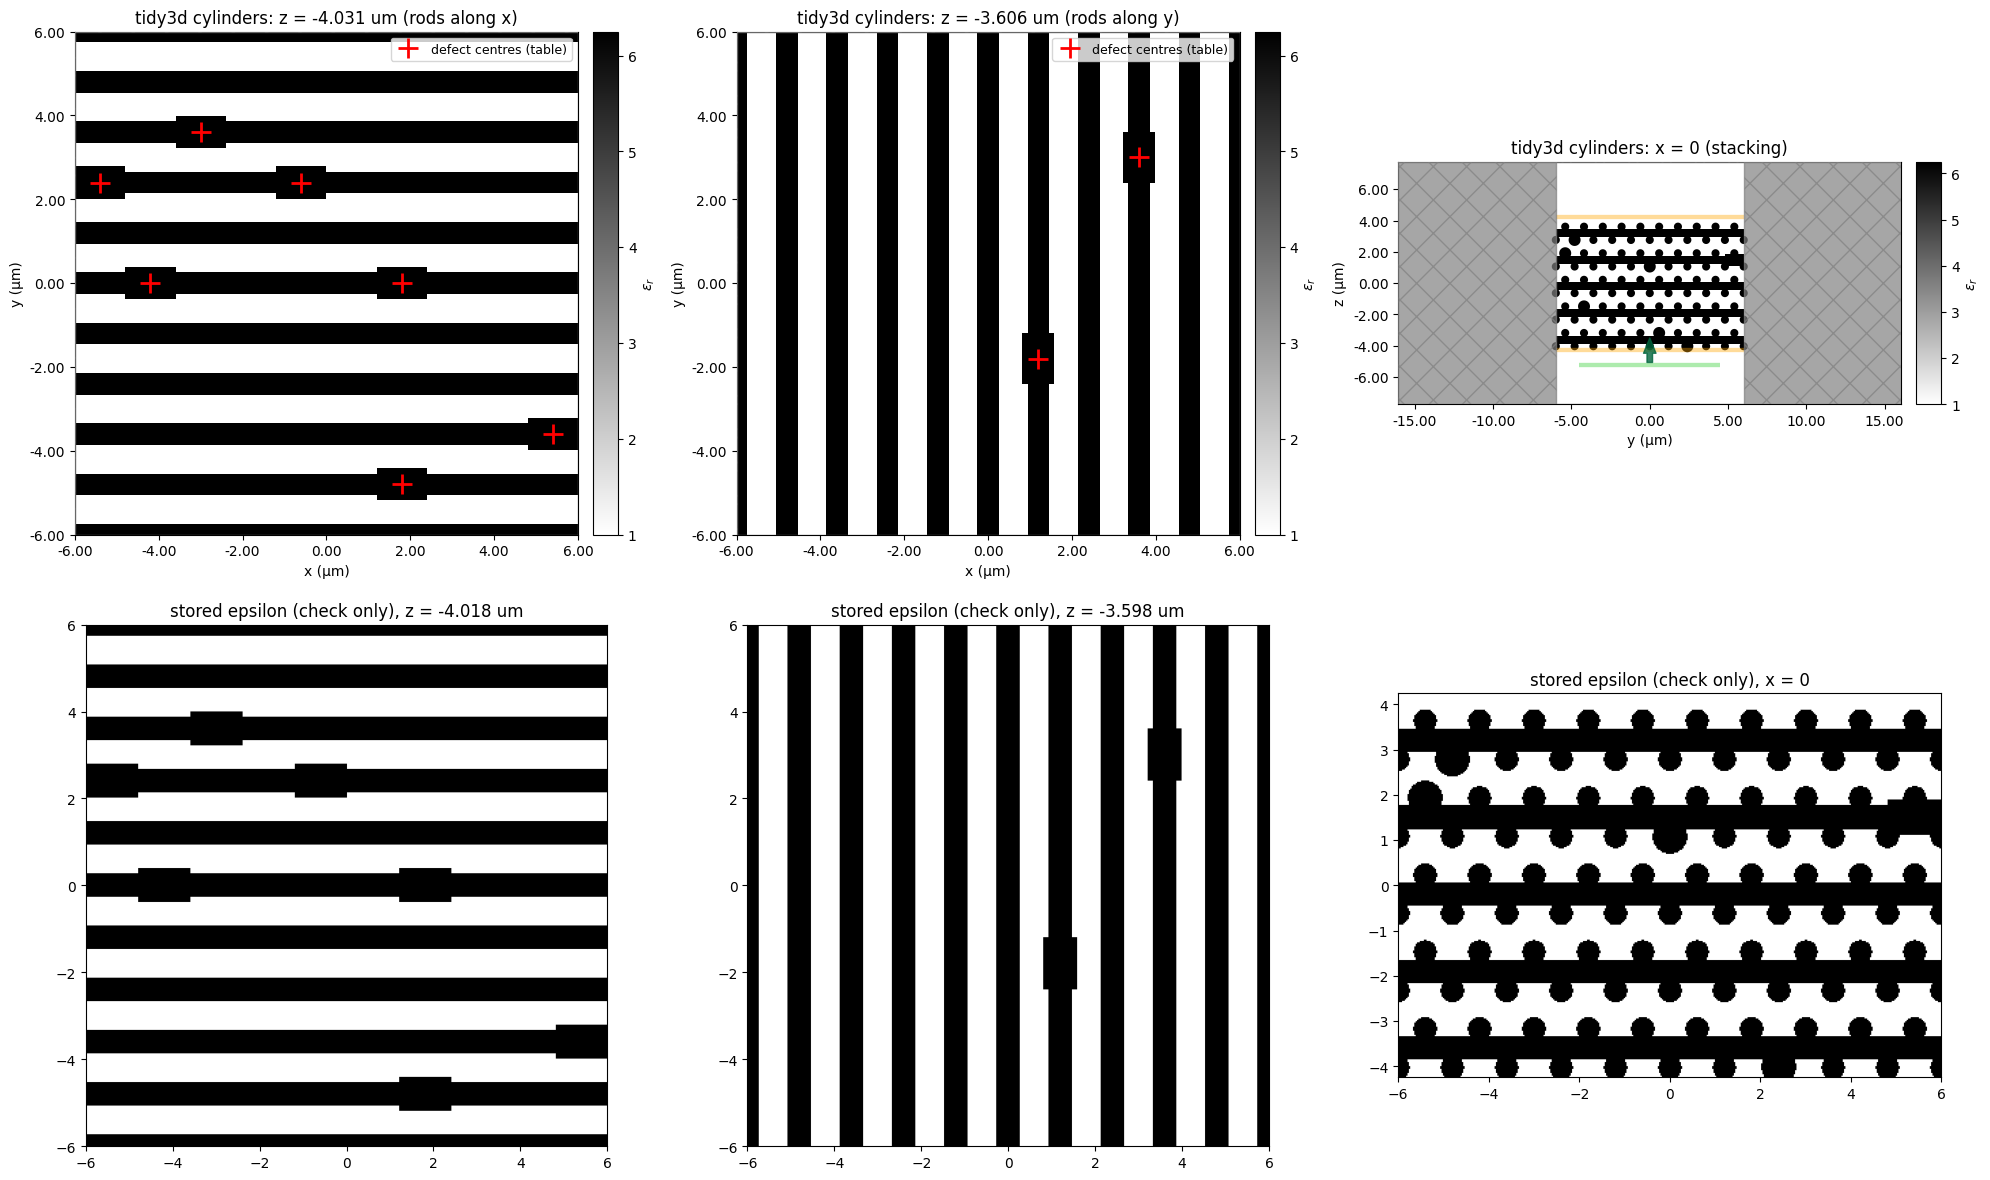

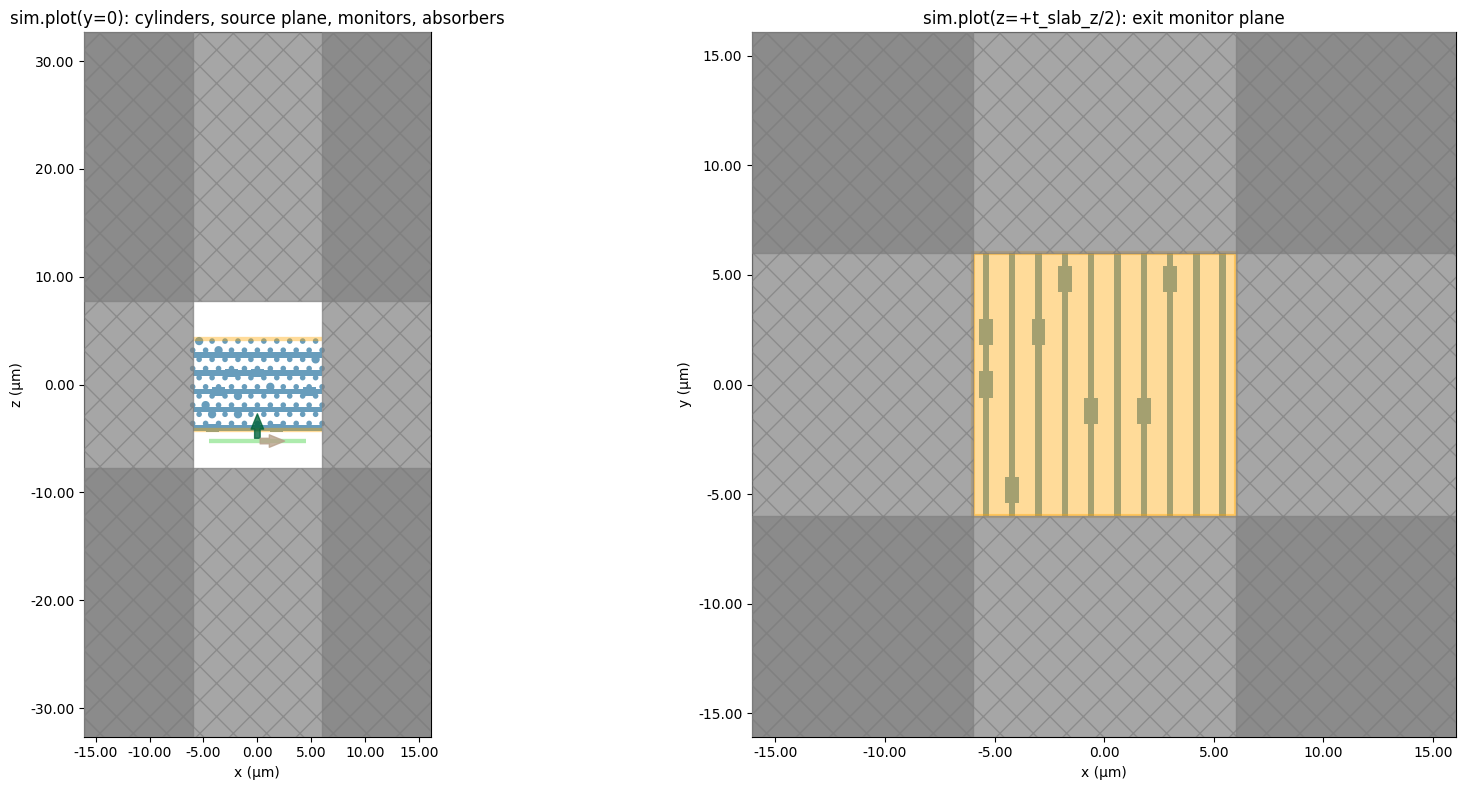

In [5]:
structure_files = sorted(p for p in folder_path.rglob("*_tables.h5"))
print("\n".join(str(p) for p in structure_files))

check_file = next((p for p in structure_files if "rho0.100" in p.name), structure_files[0])
print("\nSanity-check structure:", check_file.name)
sim_chk, sim0_chk, info_chk = build_simulation(check_file)
rods_c, def_c, par_c = info_chk["rods"], info_chk["defects"], info_chk["params"]
eps_c = AM.read_hdf5_as_dict(str(check_file))["epsilon"]      # check only

layers_z = np.unique(np.atleast_1d(rods_c["z"]))
orient_of_z = {float(z): int(np.atleast_1d(rods_c["orientation"])[np.atleast_1d(rods_c["z"]) == z][0]) for z in layers_z}
z_x = next(z for z in layers_z if orient_of_z[float(z)] == 0)        # a layer with rods along x
z_y = next(z for z in layers_z if orient_of_z[float(z)] == 1)        # a layer with rods along y
bx, by, bz = info_chk["box"]
Nx, Ny, Nz = eps_c.shape
xs = -bx/2 + (np.arange(Nx) + 0.5) * bx / Nx
ys = -by/2 + (np.arange(Ny) + 0.5) * by / Ny
zs = -bz/2 + (np.arange(Nz) + 0.5) * bz / Nz

fig, axs = plt.subplots(2, 3, figsize=(20, 12), tight_layout=True)
for j, (zl, lab) in enumerate([(z_x, "rods along x"), (z_y, "rods along y")]):
    sim_chk.plot_eps(z=float(zl), freq=f0, ax=axs[0, j])
    axs[0, j].set_title(f"tidy3d cylinders: z = {zl:.3f} um ({lab})")
    if info_chk["n_def"]:
        m = np.isclose(np.atleast_1d(def_c["z"]), zl)
        axs[0, j].plot(np.atleast_1d(def_c["x"])[m], np.atleast_1d(def_c["y"])[m], "r+", ms=14, mew=2, label="defect centres (table)")
        axs[0, j].legend(loc="upper right", fontsize=9)
    axs[0, j].set_xlim(-bx/2, bx/2); axs[0, j].set_ylim(-by/2, by/2)
    k = int(np.argmin(np.abs(zs - zl)))
    axs[1, j].imshow(eps_c[:, :, k].T, origin="lower", extent=[-bx/2, bx/2, -by/2, by/2], cmap="Greys")
    axs[1, j].set_title(f"stored epsilon (check only), z = {zs[k]:.3f} um")
sim_chk.plot_eps(x=0, freq=f0, ax=axs[0, 2]); axs[0, 2].set_title("tidy3d cylinders: x = 0 (stacking)")
axs[0, 2].set_ylim(-info_chk["Lz"]/2, info_chk["Lz"]/2)
i0 = int(np.argmin(np.abs(xs - 0)))
axs[1, 2].imshow(eps_c[i0, :, :].T, origin="lower", extent=[-by/2, by/2, -bz/2, bz/2], cmap="Greys", aspect="equal")
axs[1, 2].set_title("stored epsilon (check only), x = 0")
plt.show()

# full layout with source / monitors / absorbers
fig, axs = plt.subplots(1, 2, figsize=(18, 8), tight_layout=True)
sim_chk.plot(y=0, ax=axs[0]); axs[0].set_title("sim.plot(y=0): cylinders, source plane, monitors, absorbers")
sim_chk.plot(z=float(bz/2), ax=axs[1]); axs[1].set_title("sim.plot(z=+t_slab_z/2): exit monitor plane")
plt.show()


## Main loop — build every structure, estimate (or submit)

Bookkeeping mirrors the reference and the transmission notebook: the task ids are written to
`{tidy3d root}/data/{project_name}/n_{n_rod:.2f}/{sim_name}.txt` as two lines (`id0` of the empty-box reference, then
`id` of the structure), which is the format `AM.loadFromFile(..., get_ref=True)` expects. If the `.txt` already exists
the structure is skipped ("Exist!"). `sim_name = f"{stem}_lambda_{lambdas[1]}_{lambdas[0]}"`.

With `run = False` (default) each simulation is uploaded once under a throw-away name only to obtain `web.estimate_cost`,
then deleted; nothing is started. **Running costs money — flip `run = True` deliberately.**



=== Processing n_2.50_ff_0.3996_woodpile_d1.20_kappa+0.00_rho0.000_seednone_tables.h5
  geometry: 210 cylinders = 210 rods + 0 defects
target window        : 22.0 ps
u range              : [0.3429, 0.6000]  (span 0.2571)
max spacing          : d(nu) = 45.45 GHz,  d(a/lambda) = 1.8194e-04
points per 0.01 band : 56  (actual window 22.02 ps)
bands to cover range : 26
points, full range   : 1415  (actual window 22.01 ps)
  box = 12.0 x 12.0 x 8.4853 um, Lz = 15.485 um, n_rod = 2.5, d = 1.2 um
  source 'gaussian' at z_src = -5.243 um, waist_distance = -1.00 um (waist at z = -4.243 = entrance face -4.243), patch S = 9.0 um, w0 = 1.5 um
  monitors: exit z = +4.2426, entry z = -4.2426, 1415 freqs, d(nu) = 45.43 GHz <= 1/runtime = 45.45 GHz -> window 22.01 ps
  grid: dl_min (rods) = 0.0444 um, actual dz inside slab min/max = 0.0773/0.0773 um, dx = 0.0774 um, rod diameter / dx = 6.7, (lambda_min/n_rod)/dx = 10.3
  num_cells = 7.078e+07, num_time_steps = 149145, dt = 1.475e-16 s
  monitor data s

  estimated cost (structure run): 3.1960680582028727 FlexCredits; budget the same again for the empty-box reference sim0 (same mesh and run_time; shutoff=1e-20 will not trigger early)


  num_cells = 7.078e+07, num_time_steps = 149145, cylinders = 210, dl(rods) = 0.0444 um, monitor storage = 0.435 GB


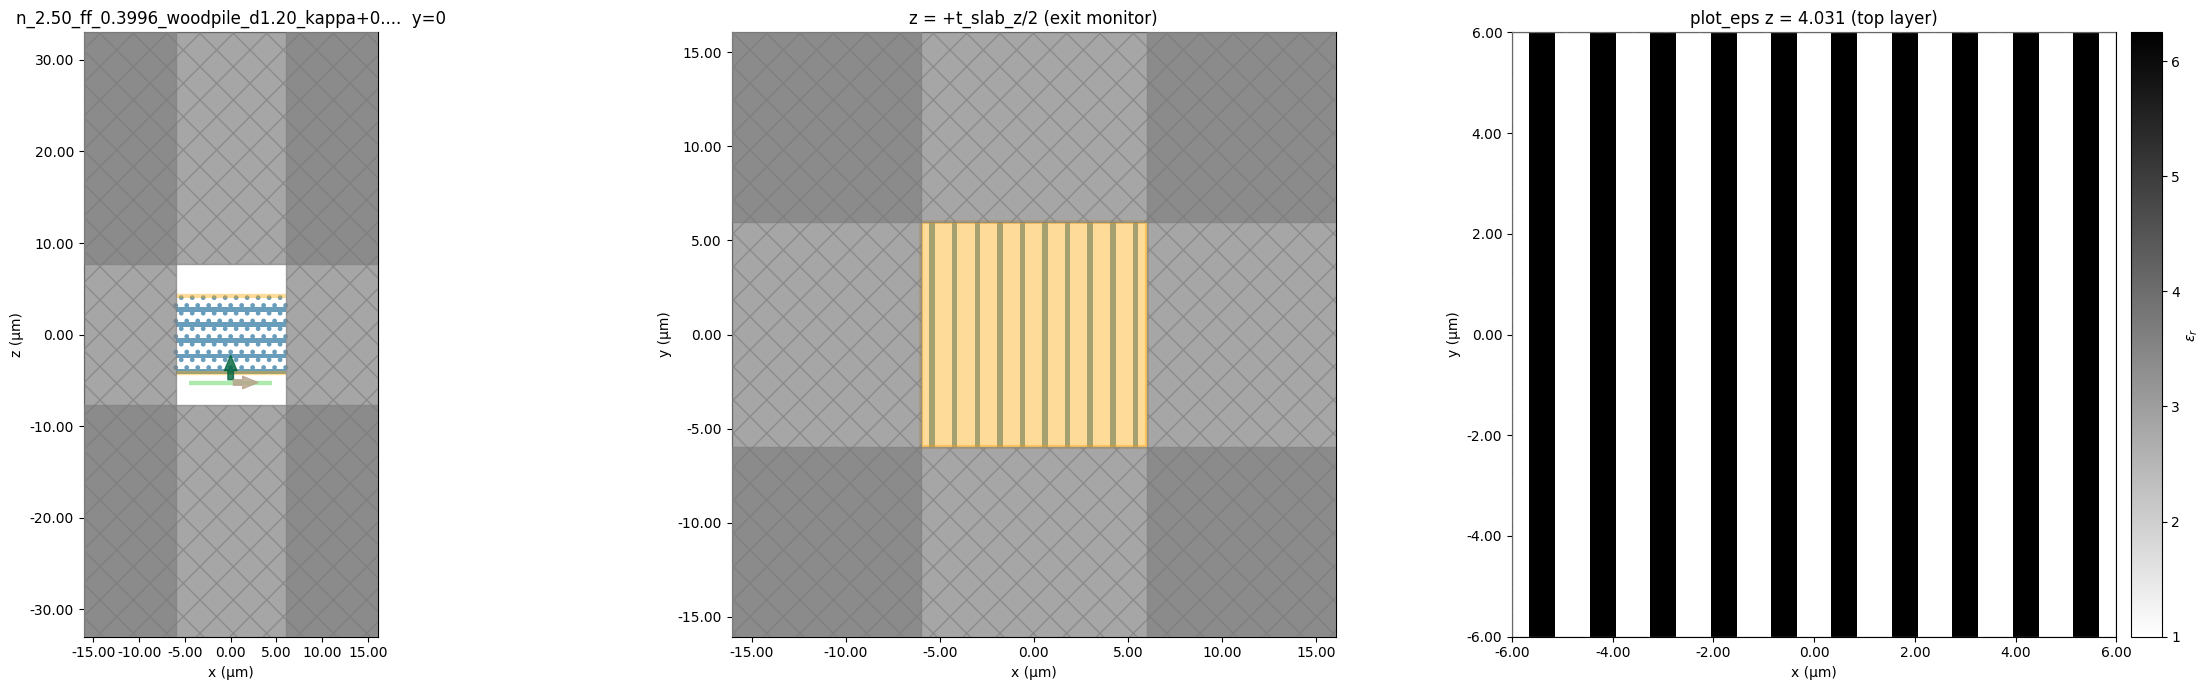


=== Processing n_2.50_ff_0.4229_woodpile_d1.20_kappa+1.20_rho0.100_seed12345_tables.h5
  geometry: 332 cylinders = 210 rods + 122 defects
target window        : 22.0 ps
u range              : [0.3429, 0.6000]  (span 0.2571)
max spacing          : d(nu) = 45.45 GHz,  d(a/lambda) = 1.8194e-04
points per 0.01 band : 56  (actual window 22.02 ps)
bands to cover range : 26
points, full range   : 1415  (actual window 22.01 ps)
  box = 12.0 x 12.0 x 8.4853 um, Lz = 15.485 um, n_rod = 2.5, d = 1.2 um
  source 'gaussian' at z_src = -5.243 um, waist_distance = -1.00 um (waist at z = -4.243 = entrance face -4.243), patch S = 9.0 um, w0 = 1.5 um
  monitors: exit z = +4.2426, entry z = -4.2426, 1415 freqs, d(nu) = 45.43 GHz <= 1/runtime = 45.45 GHz -> window 22.01 ps
  grid: dl_min (rods) = 0.0444 um, actual dz inside slab min/max = 0.0774/0.0774 um, dx = 0.0774 um, rod diameter / dx = 6.7, (lambda_min/n_rod)/dx = 10.3
  num_cells = 7.130e+07, num_time_steps = 149535, dt = 1.471e-16 s
  monitor dat

  estimated cost (structure run): 3.226131617971256 FlexCredits; budget the same again for the empty-box reference sim0 (same mesh and run_time; shutoff=1e-20 will not trigger early)


  num_cells = 7.130e+07, num_time_steps = 149535, cylinders = 332, dl(rods) = 0.0444 um, monitor storage = 0.435 GB


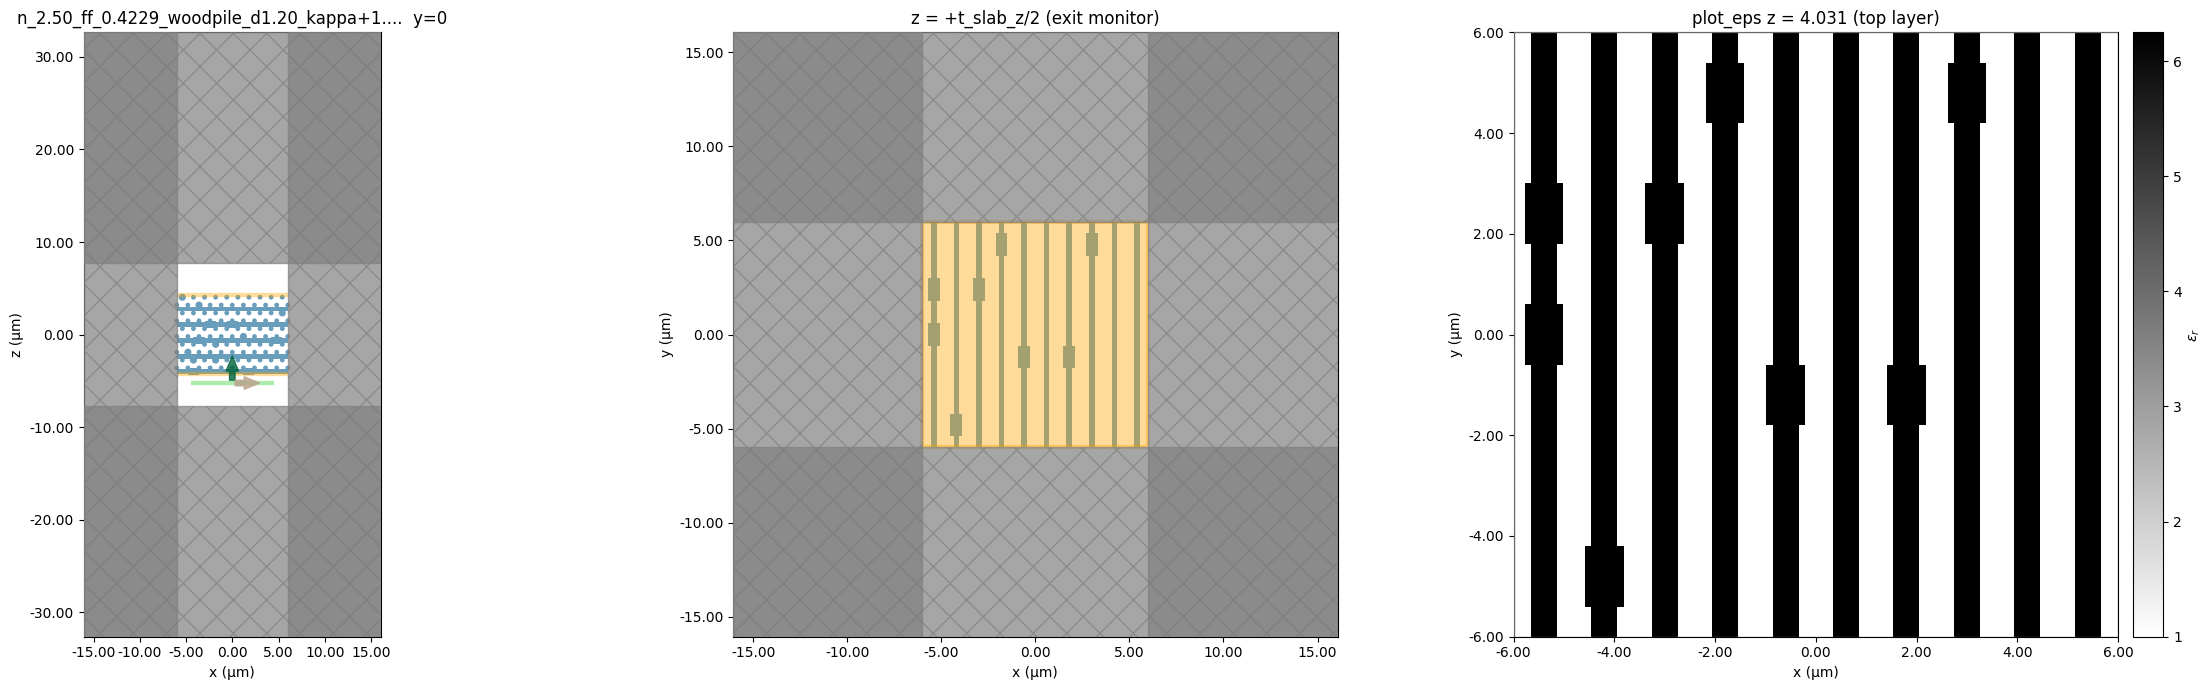


=== Processing n_2.50_ff_0.4300_woodpile_d1.20_kappa+1.60_rho0.100_seed12345_tables.h5
  geometry: 332 cylinders = 210 rods + 122 defects
target window        : 22.0 ps
u range              : [0.3429, 0.6000]  (span 0.2571)
max spacing          : d(nu) = 45.45 GHz,  d(a/lambda) = 1.8194e-04
points per 0.01 band : 56  (actual window 22.02 ps)
bands to cover range : 26
points, full range   : 1415  (actual window 22.01 ps)
  box = 12.0 x 12.0 x 8.4853 um, Lz = 15.485 um, n_rod = 2.5, d = 1.2 um
  source 'gaussian' at z_src = -5.243 um, waist_distance = -1.00 um (waist at z = -4.243 = entrance face -4.243), patch S = 9.0 um, w0 = 1.5 um
  monitors: exit z = +4.2426, entry z = -4.2426, 1415 freqs, d(nu) = 45.43 GHz <= 1/runtime = 45.45 GHz -> window 22.01 ps
  grid: dl_min (rods) = 0.0444 um, actual dz inside slab min/max = 0.0773/0.0773 um, dx = 0.0774 um, rod diameter / dx = 6.7, (lambda_min/n_rod)/dx = 10.3
  num_cells = 7.113e+07, num_time_steps = 149107, dt = 1.475e-16 s
  monitor dat

  estimated cost (structure run): 3.209887071380593 FlexCredits; budget the same again for the empty-box reference sim0 (same mesh and run_time; shutoff=1e-20 will not trigger early)


  num_cells = 7.113e+07, num_time_steps = 149107, cylinders = 332, dl(rods) = 0.0444 um, monitor storage = 0.435 GB


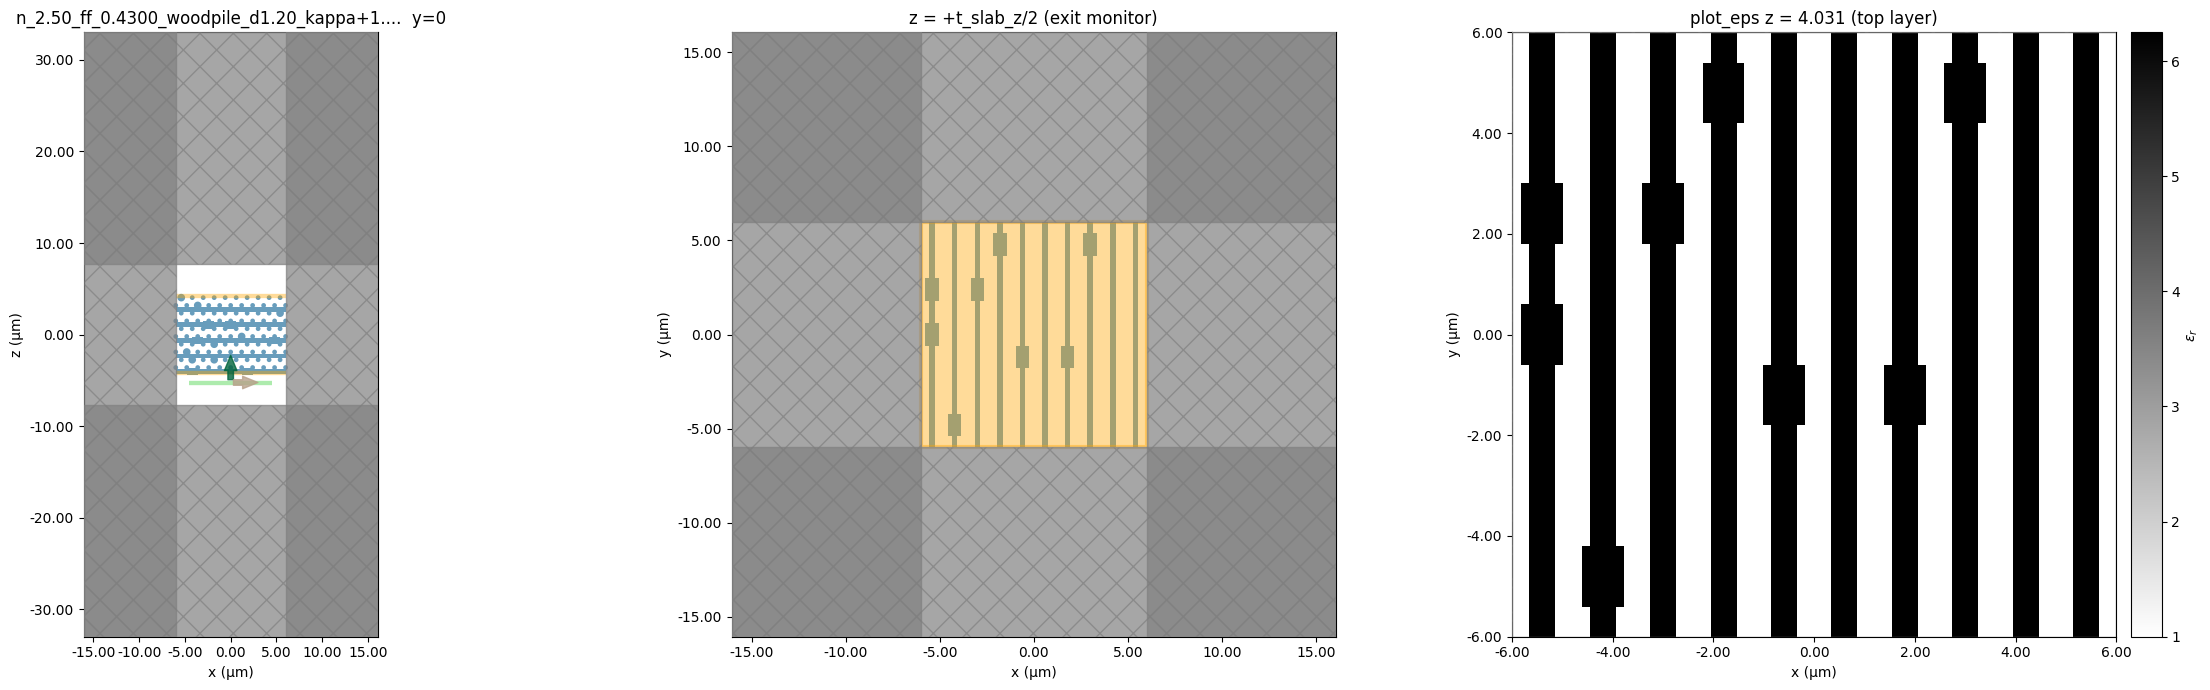


=== Processing n_2.50_ff_0.4506_woodpile_d1.20_kappa+2.80_rho0.100_seed12345_tables.h5
  geometry: 332 cylinders = 210 rods + 122 defects
target window        : 22.0 ps
u range              : [0.3429, 0.6000]  (span 0.2571)
max spacing          : d(nu) = 45.45 GHz,  d(a/lambda) = 1.8194e-04
points per 0.01 band : 56  (actual window 22.02 ps)
bands to cover range : 26
points, full range   : 1415  (actual window 22.01 ps)
  box = 12.0 x 12.0 x 8.4853 um, Lz = 15.485 um, n_rod = 2.5, d = 1.2 um
  source 'gaussian' at z_src = -5.243 um, waist_distance = -1.00 um (waist at z = -4.243 = entrance face -4.243), patch S = 9.0 um, w0 = 1.5 um
  monitors: exit z = +4.2426, entry z = -4.2426, 1415 freqs, d(nu) = 45.43 GHz <= 1/runtime = 45.45 GHz -> window 22.01 ps
  grid: dl_min (rods) = 0.0444 um, actual dz inside slab min/max = 0.0775/0.0775 um, dx = 0.0774 um, rod diameter / dx = 6.7, (lambda_min/n_rod)/dx = 10.3
  num_cells = 7.147e+07, num_time_steps = 149003, dt = 1.476e-16 s
  monitor dat

  estimated cost (structure run): 3.2223125173851486 FlexCredits; budget the same again for the empty-box reference sim0 (same mesh and run_time; shutoff=1e-20 will not trigger early)


  num_cells = 7.147e+07, num_time_steps = 149003, cylinders = 332, dl(rods) = 0.0444 um, monitor storage = 0.435 GB


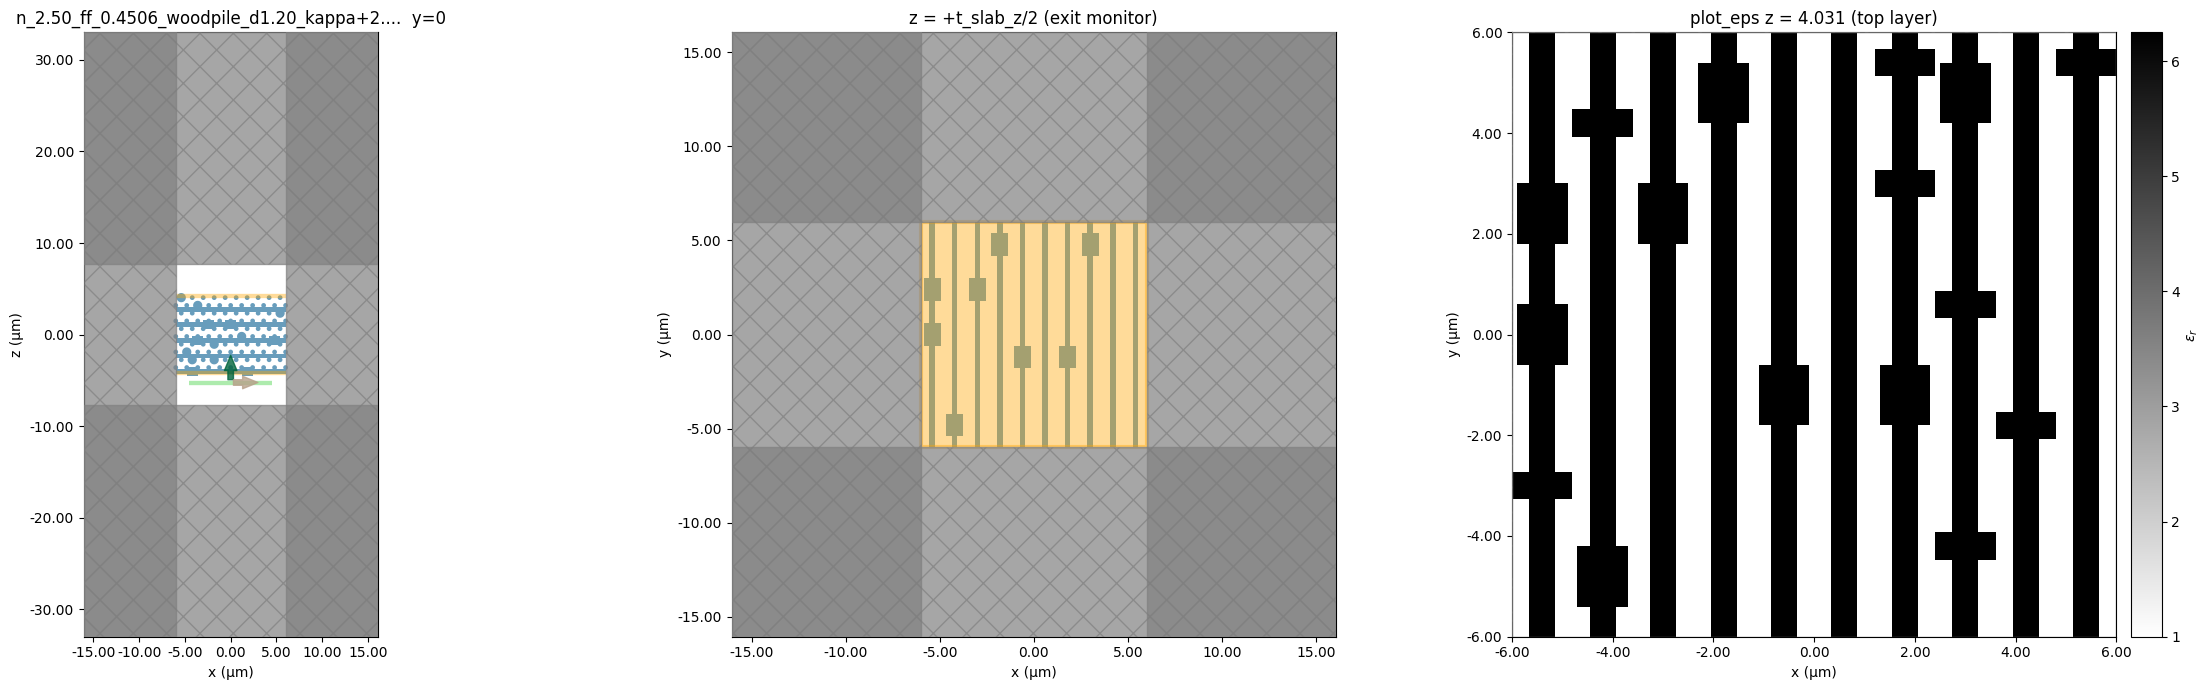

In [6]:
built = {}
for file in structure_files:
    filename = file.name
    print(f"\n=== Processing {filename}")
    sim, sim0, info = build_simulation(file)
    n_rod = info["n_rod"]
    sim_name = rf"{Path(filename).stem}_lambda_{lambdas[1]}_{lambdas[0]}"
    built[sim_name] = (sim, sim0, info)

    if run:
        folder_desc = rf"{Path.cwd().parents[2]}/data/{project_name}/n_{n_rod:.2f}"
        os.makedirs(folder_desc, exist_ok=True)
        txt = os.path.join(folder_desc, sim_name + ".txt")
        if os.path.exists(txt):
            print(txt); print("Exist!")
            continue
        # empty-box reference, once per structure (same grid as sim)
        id0 = web.upload(sim0, folder_name=project_name, task_name=sim_name + "_0", verbose=True)
        web.start(task_id=id0)
        web.monitor(id0)
        # structure
        id = web.upload(sim, folder_name=project_name, task_name=sim_name, verbose=True)
        with open(txt, "w") as fh:
            fh.write(id0 + "\n" + id)
        web.start(task_id=id)
        web.monitor(id)
    else:
        # throw-away upload to get the cost estimate, then delete (nothing is started)
        id_test = web.upload(sim, folder_name=project_name, task_name="test_" + sim_name, verbose=False)
        try:
            cost = web.estimate_cost(id_test, verbose=False)
            print(f"  estimated cost (structure run): {cost} FlexCredits; budget the same again for the empty-box "
                  f"reference sim0 (same mesh and run_time; shutoff=1e-20 will not trigger early)")
        finally:
            web.delete(id_test)
        print(f"  num_cells = {sim.num_cells:.3e}, num_time_steps = {sim.num_time_steps}, cylinders = {info['n_cyl']}, "
              f"dl(rods) = {info['dl']:.4f} um, monitor storage = {sum(sim.monitors_data_size.values())/1e9:.3f} GB")
        fig, axs = plt.subplots(1, 3, figsize=(24, 7), tight_layout=True)
        sim.plot(y=0, ax=axs[0]); axs[0].set_title(f"{Path(filename).stem[:40]}...  y=0")
        sim.plot(z=float(info['box'][2]/2), ax=axs[1]); axs[1].set_title("z = +t_slab_z/2 (exit monitor)")
        z_layer = float(np.max(np.atleast_1d(info["rods"]["z"])))
        sim.plot_eps(z=z_layer, freq=f0, ax=axs[2]); axs[2].set_title(f"plot_eps z = {z_layer:.3f} (top layer)")
        axs[2].set_xlim(-info['box'][0]/2, info['box'][0]/2); axs[2].set_ylim(-info['box'][1]/2, info['box'][1]/2)
        plt.show()


## Verification 1 — waist position and sign of `waist_distance` (analytic, no cloud run)

tidy3d's `GaussianBeamProfile` (the same analytic beam the `GaussianBeam` source injects) is evaluated in free space
on the *entrance-face* plane, 1 µm in front of the source plane, for both signs of `waist_distance`. The 1/e² intensity
radius there must equal `w0` for the sign used in `build_simulation` (negative) and `w(1 µm + 1 µm) = w0·√(1+(2/z_R)²)`
for the other sign (waist 1 µm behind the source, so 2 µm from the face).


In [7]:
from tidy3d.components.beam import GaussianBeamProfile

def measured_radius_1e2(x, I):
    '''1/e^2 intensity radius of a centred profile I(x) (interpolated crossing).'''
    I = I / I.max()
    xp = x[x >= 0]; Ip = I[x >= 0]
    k = np.flatnonzero(Ip < np.exp(-2))[0]
    return xp[k-1] + (np.exp(-2) - Ip[k-1]) * (xp[k] - xp[k-1]) / (Ip[k] - Ip[k-1])

sim_v, _, info_v = build_simulation(structure_files[0], verbose=False)
S_v, z_src_v, wd_v = info_v["S"], info_v["z_src"], info_v["waist_distance"]
z_face_v = -info_v["box"][2] / 2
dist = z_face_v - z_src_v                     # +1 um: face is in FRONT of the source plane
xx = np.linspace(-S_v/2, S_v/2, 801)
print(f"source plane z_src = {z_src_v:.3f}, entrance face z = {z_face_v:.3f}, face - source = {dist:+.2f} um, w0 = {w0} um")
for wd in (wd_v, -wd_v):
    prof = GaussianBeamProfile(center=(0, 0, z_src_v), size=(S_v, S_v, 0), freqs=[f0], waist_radius=w0,
                               waist_distance=wd, direction='+', pol_angle=0)
    # tidy3d's own beam parametrisation: w(z) with z measured from the source plane along propagation
    k0 = 2 * np.pi * f0 / td.C_0
    w_z = float(np.ravel(prof.beam_params(np.array([dist]), np.array([k0]))[0])[0])
    I = (w0 / w_z)**2 * np.exp(-2 * xx**2 / w_z**2)          # |scalar_field|^2 on the face
    w_meas = measured_radius_1e2(xx, I)
    lam0 = td.C_0 / f0; zR = np.pi * w0**2 / lam0
    w_expect = w0 * np.sqrt(1 + ((dist + wd) / zR)**2)
    tag = "USED in build_simulation" if wd == wd_v else "opposite sign"
    print(f"  waist_distance = {wd:+.2f} um ({tag}): 1/e^2 radius on the entrance face = {w_meas:.4f} um "
          f"(analytic w(z) = {w_expect:.4f} um; w0 = {w0})")


  geometry: 210 cylinders = 210 rods + 0 defects
target window        : 22.0 ps
u range              : [0.3429, 0.6000]  (span 0.2571)
max spacing          : d(nu) = 45.45 GHz,  d(a/lambda) = 1.8194e-04
points per 0.01 band : 56  (actual window 22.02 ps)
bands to cover range : 26
points, full range   : 1415  (actual window 22.01 ps)
source plane z_src = -5.243, entrance face z = -4.243, face - source = +1.00 um, w0 = 1.5 um
  waist_distance = -1.00 um (USED in build_simulation): 1/e^2 radius on the entrance face = 1.5000 um (analytic w(z) = 1.5000 um; w0 = 1.5)
  waist_distance = +1.00 um (opposite sign): 1/e^2 radius on the entrance face = 1.8486 um (analytic w(z) = 1.8485 um; w0 = 1.5)
